# 03_02 · IM：三种采样时钟的价格、收益分布与时序诊断

只读 `03_01_im_clock_resampling.ipynb` 已生成的采样映射和价格两份 Parquet，每次只比较**同一粒度下的时间／全合约成交量／全合约成交额三种时钟**。参数 `equivalent_minutes` 默认 5，可切换为 10 或 15；不将不同粒度放在同组图中比较。使用 latitude_env_v2 内核，从头运行。

1. 自然时间上的价格叠图，以及采样序号上的 log 价格图，展示不同采样时钟对同一价格路径的观察方式。
2. 直接使用已有的区间 `log_return`，乘 $10^4$ 表示为 log 收益基点（bp）；首个参考点没有收益，不填零，不跨 train/test 差分。
3. 每组训练段**全量收益**分别拟合正态分布与五参数广义双曲分布（GH）；测试段沿用训练参数，比较平均 log likelihood。展示训练／测试收益直方图、密度曲线及尾部频图。
4. 分 train/test 描述均值、标准差、偏度、超额峰度、分位数、零收益与时长；绘制收益和平方收益 ACF，并给出 JB、Ljung–Box、ARCH-LM 与 ADF 诊断。

这里的“频图”按旧 Notebook 的用法指频数／概率密度直方图。图中裁切仅影响可见范围；拟合、似然和统计描述使用全部有效区间，不剔除尾部、不缩尾。归一化直方图以完整样本数为分母，避免隐藏尾部后重新放大中央密度。

参考旧 Notebook 的价格图和分布图思路；旧例把已经差分的 log 收益再次 `.diff()`，且没有实际叠加正态曲线，本实现直接使用上游收益并画出两个模型。旧归档只读，不导入或执行。

**解释边界**：上游价格是全快照首尾锚定复权，历史价格含未来换月依赖；下面的 train/test 只隔离分布参数拟合，不能视为无未来信息的预测检验。事件时钟中的一个 lag 是一个采样区间，并非固定日历时长。同一来源分钟可被拆出多个收益，线性插值本身会制造相关性；诊断是探索性描述，不把显著性直接解释为可交易性。

图表、统计量和简要结论均在本 Notebook 内展示。

**阶段阅读导航**：[01_01 主力连续价格](01_01_im_main_continuous.ipynb) → [02_01 BPV季节因子](02_01_im_bpv_intraday_seasonality.ipynb)（[02_02 窗口比较](02_02_im_bpv_window_comparison.ipynb)）→ [03_01 采样时钟与价格](03_01_im_clock_resampling.ipynb)（[03_02 时钟诊断](03_02_im_clock_comparison_diagnostics.ipynb)）→ [04_01 波动观测量](04_01_im_volatility_observations.ipynb) → [04_02 每日拟合](04_02_im_volatility_model_fitting.ipynb) → [04_03 下一采样步预测](04_03_im_next_step_volatility_forecasting.ipynb)／[04_04 未来15分钟预测](04_04_im_15m_volatility_forecasting.ipynb)。括号中的比较与诊断本用于查看对应阶段结果，不是下一阶段的数据生成依赖；最后两本预测相互独立。


## 1. 参数与读取契约

In [1]:
import pathlib
import sys

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()  # 当前工作目录

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")

from config.settings import settings

import json
import time
import warnings
from zoneinfo import ZoneInfo
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from scipy import stats, optimize
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import acf, adfuller
from IPython.display import display, Markdown
from config.data_contracts import validate_arrow_table, arrow_to_pandas

research_dir = candidate_root / "01_project_collection/JQ_strategy/draft_experiments"
map_path = research_dir / "im_clock_sampling_map.parquet"
price_path = research_dir / "im_clock_sampled_prices.parquet"
equivalent_minutes = 5  # 本次比较的唯一粒度：5 / 10 / 15
if equivalent_minutes not in (5, 10, 15):
    raise ValueError("equivalent_minutes 必须为 5、10 或 15")
clocks = ("time", "volume", "money")
clock_labels = {"time": "时间", "volume": "成交量", "money": "成交额"}
clock_colors = {"time": "#2563EB", "volume": "#D97706", "money": "#059669"}
granularities = (equivalent_minutes,)
splits = ("train", "test")
acf_lags = 40
diagnostic_lag = 10
histogram_bins = 80
central_quantiles = (0.002, 0.998)
gh_max_iterations = 150
gh_max_evaluations = 1200
plt.rcParams.update({
    "font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False, "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.16, "font.size": 10,
})
market_zone = ZoneInfo("Asia/Shanghai")

# 本实验只读所需列的显式 Arrow 投影；表级身份与主键从上游 metadata 读取。
key_fields = [
    pa.field("clock", pa.string(), False),
    pa.field("equivalent_minutes", pa.int16(), False),
    pa.field("split", pa.string(), False),
    pa.field("sample_number", pa.int64(), False),
]
price_schema = pa.schema([
    *key_fields,
    pa.field("sample_at", pa.timestamp("us", tz="Asia/Shanghai"), False),
    pa.field("previous_sample_at", pa.timestamp("us", tz="Asia/Shanghai")),
    pa.field("has_previous_sample", pa.bool_(), False),
    pa.field("price", pa.float64(), False),
    pa.field("log_price", pa.float64(), False),
    pa.field("log_return", pa.float64()),
    pa.field("duration_seconds", pa.float64()),
    pa.field("trading_duration_minutes", pa.float64()),
    pa.field("nontrading_duration_seconds", pa.float64()),
    pa.field("interval_volume", pa.float64()),
    pa.field("interval_money", pa.float64()),
    pa.field("available_at", pa.timestamp("us", tz="Asia/Shanghai"), False),
])
map_schema = pa.schema([
    *key_fields,
    pa.field("sample_at", pa.timestamp("us", tz="Asia/Shanghai"), False),
    pa.field("source_minute_index", pa.int64(), False),
    pa.field("previous_source_minute_index", pa.int64()),
    pa.field("minute_fraction", pa.float64(), False),
])
display(pd.DataFrame([
    {"schema": name, "field": field.name, "type": str(field.type), "nullable": field.nullable}
    for name, schema in [("price_projection", price_schema), ("map_projection", map_schema)]
    for field in schema
]))
print(sys.executable)


,schema,field,type,nullable
0,price_projection,clock,string,False
1,price_projection,equivalent_minutes,int16,False
2,price_projection,split,string,False
3,price_projection,sample_number,int64,False
4,price_projection,sample_at,"timestamp[us, tz=Asia/Shanghai]",False
5,price_projection,previous_sample_at,"timestamp[us, tz=Asia/Shanghai]",True
6,price_projection,has_previous_sample,bool,False
7,price_projection,price,double,False
8,price_projection,log_price,double,False
9,price_projection,log_return,double,True


E:\anaconda3\envs\latitude\python.exe


## 2. 确认两表身份、价格与收益

复用上游 metadata 中的采样身份、主键、校准、插值和复权口径；只读取本诊断需要的字段。

In [2]:
price_file_schema = pq.read_schema(price_path)
map_file_schema = pq.read_schema(map_path)
price_metadata = price_file_schema.metadata or {}
map_metadata = map_file_schema.metadata or {}
for metadata_key in [b"sampling_map_id", b"sampling_metadata", b"primary_key"]:
    if metadata_key not in price_metadata or price_metadata[metadata_key] != map_metadata.get(metadata_key):
        raise ValueError(f"两份文件身份／契约不一致：{metadata_key!r}")
sampling_metadata = json.loads(price_metadata[b"sampling_metadata"])
if sampling_metadata["format_version"] != "2.0.0":
    raise ValueError("需要当前 2.0.0 close→close log 插值格式")
sample_keys = price_metadata[b"primary_key"].decode().split(",")
if sample_keys != [field.name for field in key_fields]:
    raise ValueError("上游主键不符合本诊断输入契约")
sampling_map_id = price_metadata[b"sampling_map_id"].decode()
anchor_at = pd.Timestamp(sampling_metadata["anchor_at"])

price_table = validate_arrow_table(pq.read_table(price_path, columns=price_schema.names, filters=[("equivalent_minutes", "=", equivalent_minutes)]), price_schema)
map_table = validate_arrow_table(pq.read_table(map_path, columns=map_schema.names, filters=[("equivalent_minutes", "=", equivalent_minutes)]), map_schema)
price_df = arrow_to_pandas(price_table, price_schema).sort_values(sample_keys).reset_index(drop=True)
map_df = arrow_to_pandas(map_table, map_schema).sort_values(sample_keys).reset_index(drop=True)
pd.testing.assert_frame_equal(price_df[sample_keys + ["sample_at"]], map_df[sample_keys + ["sample_at"]])
if price_df.duplicated(sample_keys).any():
    raise ValueError("诊断输入不能有重复采样键")
for column in ["sample_at", "previous_sample_at", "available_at"]:
    price_df[column] = pd.to_datetime(price_df[column])
price_df["same_source_minute"] = (
    map_df["source_minute_index"].eq(map_df["previous_source_minute_index"]).fillna(False)
).to_numpy(dtype=bool)
has_return = price_df["has_previous_sample"].to_numpy(dtype=bool)
if price_df.loc[~has_return, "log_return"].notna().any():
    raise ValueError("首个参考点不应有跨界收益")
if not np.isfinite(price_df.loc[has_return, "log_return"].to_numpy(dtype=float)).all():
    raise ValueError("有效区间收益存在缺失或非有限数")
interval_df = price_df.loc[has_return].copy()
interval_df["return_bp"] = interval_df["log_return"].astype("float64") * 10000.0

price_by_group = dict(tuple(price_df.groupby(["equivalent_minutes", "clock", "split"], observed=True)))
interval_by_group = dict(tuple(interval_df.groupby(["equivalent_minutes", "clock", "split"], observed=True)))
expected_groups = {(g, c, s) for g in granularities for c in clocks for s in splits}
if set(price_by_group) != expected_groups or set(interval_by_group) != expected_groups:
    raise ValueError("缺少所选粒度 × 3 时钟 × 2 split 中的组合")
for group, series_df in price_by_group.items():
    if not series_df["sample_at"].is_monotonic_increasing:
        raise ValueError(f"时间顺序不正确：{group}")
    # 只核对本次诊断使用的收益定义，避免再次差分或跨 split 计算收益。
    np.testing.assert_allclose(
        series_df["log_price"].to_numpy(dtype=float)[1:] - series_df["log_price"].to_numpy(dtype=float)[:-1],
        interval_by_group[group]["log_return"].to_numpy(dtype=float), rtol=0, atol=2e-14,
    )

coverage_df = price_df.groupby(["equivalent_minutes", "clock", "split"], observed=True).agg(
    point_count=("sample_number", "size"),
    first_point=("sample_at", "min"), last_point=("sample_at", "max"),
)
coverage_df["interval_count"] = coverage_df["point_count"] - 1
display(coverage_df)
print("映射身份:", sampling_map_id)
print("插值口径:", sampling_metadata["price_interpolation"])
print("上游价格依赖:", sampling_metadata["price_adjustment_scope"])


point_count               first_point                       last_point  interval_count
equivalent_minutes clock  split                                                                                        
5                  money  test          6771 2026-06-01 09:30:00+08:00 2026-08-28 14:58:16.606440+08:00            6770
                          train        44689 2022-07-25 09:30:00+08:00        2026-05-29 15:00:00+08:00           44688
                   time   test          3073 2026-06-01 09:30:00+08:00        2026-08-28 15:00:00+08:00            3072
                          train        44689 2022-07-25 09:30:00+08:00        2026-05-29 15:00:00+08:00           44688
                   volume test          5571 2026-06-01 09:30:00+08:00 2026-08-28 14:57:44.434332+08:00            5570
                          train        44689 2022-07-25 09:30:00+08:00        2026-05-29 15:00:00+08:00           44688

映射身份: d4be9dd968bc2f676d913d25285ba1c1eadc4501244a1c840767f8b116357525
插值口径: log_price=(1-fraction)*log(previous trading minute close)+fraction*log(current close); price=exp(log_price)
上游价格依赖: whole-snapshot retrospective dual endpoint adjustment


## 3. 三种时钟的价格走势

自然时间叠图使用真实价格点；采样序号图将每个区间等距排列。同一粒度的事件轴共用横向范围，紫色虚线标出训练／测试边界；各 split 分别绘制。

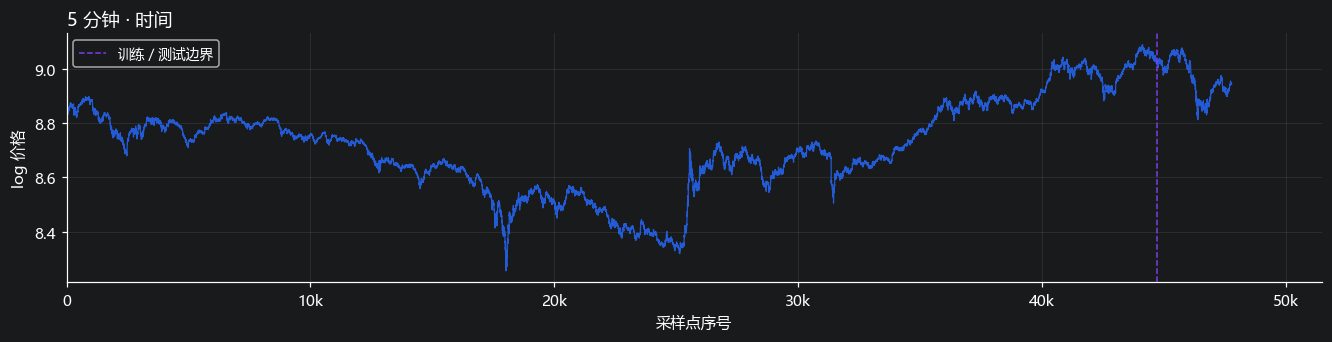

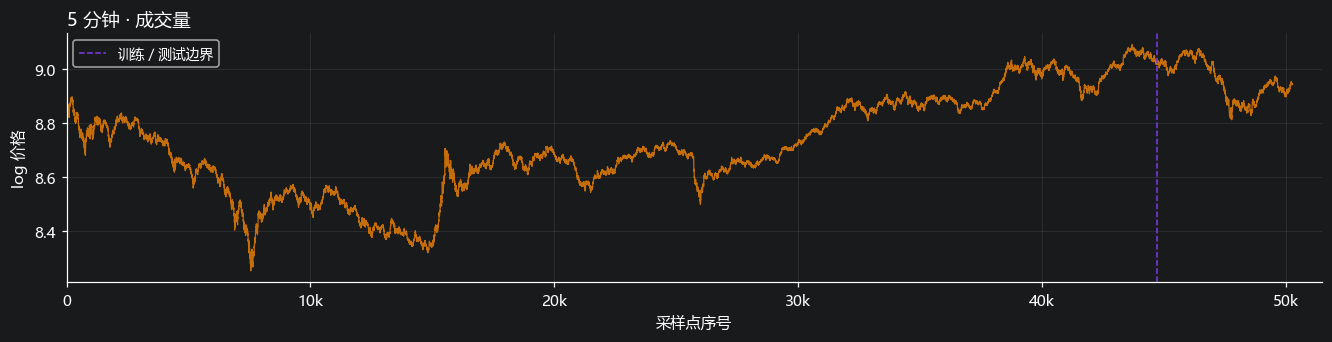

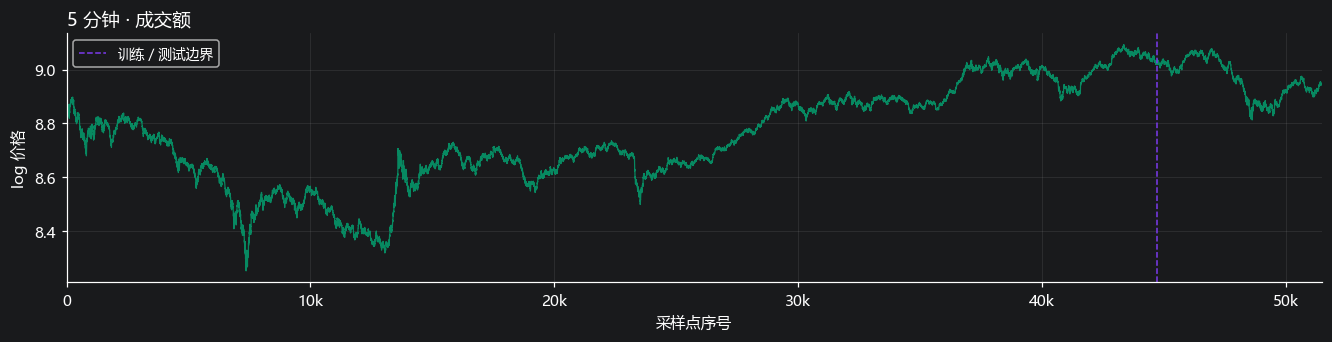

In [5]:
# 只画原来的第二张图：把 3 个子图拆成 3 张独立图
for granularity in granularities:
    row_max_count = max(
        sum(len(price_by_group[(granularity, c, s)]) for s in splits)
        for c in clocks
    )

    for clock in clocks:
        figure, axis = plt.subplots(1, 1, figsize=(12, 3), layout="constrained")

        train_count = len(price_by_group[(granularity, clock, "train")])

        for split in splits:
            series_df = price_by_group[(granularity, clock, split)]
            positions = np.arange(len(series_df)) + (0 if split == "train" else train_count)

            axis.plot(
                positions,
                series_df["log_price"].to_numpy(dtype=float),
                color=clock_colors[clock],
                linewidth=0.8,
                alpha=0.9,
            )

        # 训练 / 测试边界
        axis.axvline(
            train_count - 0.5,
            color="#7C3AED",
            linestyle="--",
            linewidth=1.0,
            label="训练／测试边界",
        )

        axis.set_xlim(0, row_max_count)
        axis.set_title(f"{granularity} 分钟 · {clock_labels[clock]}", loc="left")
        axis.set_xlabel("采样点序号")
        axis.set_ylabel("log 价格")
        axis.xaxis.set_major_formatter(mticker.EngFormatter(sep=""))
        axis.legend(loc="upper left", fontsize=9)

        # figure.suptitle("采样时钟如何改变价格路径的横向展开", fontsize=16)


        plt.show()
        plt.close(figure)

## 4. 正态与广义双曲分布拟合

训练数据先以训练均值和标准差改善数值条件，GH 的五个参数均参与优化；结果转换回 log 收益 bp 单位。正态 MLE 直接使用训练均值与总体标准差。拟合全量样本，不进行尾部裁切。

SciPy 的参数为 $(p,a,b,\mathrm{loc},\mathrm{scale})$，传统参数对应 $\lambda=p,\ \delta=\mathrm{scale},\ \mu=\mathrm{loc},\ \alpha=a/\delta,\ \beta=b/\delta$；不能直接把 SciPy 的 $a,b$ 当作传统 $\alpha,\beta$，也不存在“GH 的 $\alpha$ 必须小于 2”的规则。[SciPy 参数说明](https://docs.scipy.org/doc/scipy-1.16.2/reference/generated/scipy.stats.genhyperbolic.html)。

GH 使用有界数值优化，记录收敛与边界；这不是全局最优保证。表中的 AIC/BIC 仅计算训练拟合，且只能在同一采样方案、同一批收益内比较正态和 GH。测试期以平均 log likelihood 评估训练密度，不在测试段重新拟合。

In [4]:
def fit_gh_distribution(training_return_bp):
    """全训练样本的五参数 GH 数值 MLE；记录收敛和边界，不裁切数据。"""
    fit_center = float(np.mean(training_return_bp))
    fit_scale = float(np.std(training_return_bp, ddof=0))
    if fit_scale <= 0 or len(training_return_bp) < 30:
        raise ValueError("GH 拟合需要非退化且至少 30 个训练区间")
    standardized_returns = (training_return_bp - fit_center) / fit_scale

    # a=exp(log_a)、b=a*tanh(eta)、scale=exp(log_scale)，严格保证 a>|b| 和正尺度。
    # 有限搜索盒用于数值稳定；触及边界会在结果中明示。
    parameter_bounds = [(-10, 10), (-8, 6), (-4, 4), (-5, 5), (-8, 4)]
    initial_parameters = np.array([-0.5, 0.0, 0.0, 0.0, -0.5])

    def negative_mean_log_likelihood(parameters):
        p, log_a, eta, location, log_scale = parameters
        a = np.exp(log_a)
        b = a * np.tanh(eta)
        log_density = stats.genhyperbolic.logpdf(
            standardized_returns, p, a, b, loc=location, scale=np.exp(log_scale)
        )
        if not np.isfinite(log_density).all():
            return 1e100
        return -float(np.mean(log_density))

    started_at = time.monotonic()
    optimization = optimize.minimize(
        negative_mean_log_likelihood, initial_parameters, method="L-BFGS-B",
        bounds=parameter_bounds,
        options={"maxiter": gh_max_iterations, "maxfun": gh_max_evaluations, "ftol": 1e-10, "gtol": 1e-5},
    )
    p, log_a, eta, location, log_scale = optimization.x
    a = float(np.exp(log_a))
    b = float(a * np.tanh(eta))
    location_bp = float(fit_center + fit_scale * location)
    scale_bp = float(fit_scale * np.exp(log_scale))
    fitted_parameters = (float(p), a, b, location_bp, scale_bp)
    if not np.isfinite(stats.genhyperbolic.logpdf(training_return_bp, *fitted_parameters)).all():
        raise ValueError("GH 最终拟合产生非有限密度，停止发布")
    boundary_hit = any(
        abs(value - lower) < 1e-4 or abs(value - upper) < 1e-4
        for value, (lower, upper) in zip(optimization.x, parameter_bounds)
    )
    return {
        "parameters": fitted_parameters, "success": bool(optimization.success),
        "message": str(optimization.message), "iterations": int(optimization.nit),
        "function_evaluations": int(optimization.nfev), "boundary_hit": boundary_hit,
        "fit_seconds": time.monotonic() - started_at,
        "standardization_mean_bp": fit_center, "standardization_std_bp": fit_scale,
    }

fit_by_group = {}
fit_rows = []
evaluation_rows = []
for granularity in granularities:
    for clock in clocks:
        training_returns = interval_by_group[(granularity, clock, "train")]["return_bp"].to_numpy(dtype=float)
        print(f"拟合 {granularity} 分钟 · {clock_labels[clock]}：{len(training_returns):,} 个训练收益", flush=True)
        normal_parameters = tuple(float(value) for value in stats.norm.fit(training_returns))
        gh_fit = fit_gh_distribution(training_returns)
        gh_parameters = gh_fit["parameters"]
        fit_by_group[(granularity, clock)] = {"normal": normal_parameters, "gh": gh_parameters}
        fit_rows.append({
            "equivalent_minutes": granularity, "clock": clock,
            "train_count": len(training_returns),
            "normal_mean_bp": normal_parameters[0], "normal_std_bp": normal_parameters[1],
            "gh_p": gh_parameters[0], "gh_a": gh_parameters[1], "gh_b": gh_parameters[2],
            "gh_loc_bp": gh_parameters[3], "gh_scale_bp": gh_parameters[4],
            "gh_alpha_per_bp": gh_parameters[1] / gh_parameters[4],
            "gh_beta_per_bp": gh_parameters[2] / gh_parameters[4],
            **{key: value for key, value in gh_fit.items() if key != "parameters"},
        })
        for split in splits:
            returns = interval_by_group[(granularity, clock, split)]["return_bp"].to_numpy(dtype=float)
            for model, distribution, parameters, parameter_count in [
                ("normal", stats.norm, normal_parameters, 2),
                ("gh", stats.genhyperbolic, gh_parameters, 5),
            ]:
                log_likelihood = distribution.logpdf(returns, *parameters)
                if not np.isfinite(log_likelihood).all():
                    raise ValueError(f"{granularity}/{clock}/{split}/{model} 出现非有限似然")
                log_likelihood_sum = float(log_likelihood.sum())
                evaluation_rows.append({
                    "equivalent_minutes": granularity, "clock": clock, "split": split,
                    "model": model, "sample_count": len(returns),
                    "mean_log_likelihood": float(log_likelihood.mean()),
                    "log_likelihood": log_likelihood_sum,
                    "aic": 2 * parameter_count - 2 * log_likelihood_sum if split == "train" else None,
                    "bic": parameter_count * np.log(len(returns)) - 2 * log_likelihood_sum if split == "train" else None,
                })
        print(f"  GH 收敛={gh_fit['success']}，边界={gh_fit['boundary_hit']}，耗时={gh_fit['fit_seconds']:.1f}s", flush=True)

fit_df = pd.DataFrame(fit_rows)
evaluation_df = pd.DataFrame(evaluation_rows)
fit_comparison_df = evaluation_df.pivot(
    index=["equivalent_minutes", "clock", "split"], columns="model", values="mean_log_likelihood"
)
fit_comparison_df["gh_minus_normal"] = fit_comparison_df["gh"] - fit_comparison_df["normal"]
display(fit_df)
display(fit_comparison_df)
if not fit_df["success"].all() or fit_df["boundary_hit"].any():
    display(Markdown("**部分 GH 拟合未收敛或触及搜索边界；参数和似然仅作候选结果，详见上表。**"))


拟合 5 分钟 · 时间：44,688 个训练收益


  GH 收敛=True，边界=False，耗时=13.6s


拟合 5 分钟 · 成交量：44,688 个训练收益


  GH 收敛=True，边界=False，耗时=25.2s


拟合 5 分钟 · 成交额：44,688 个训练收益


  GH 收敛=True，边界=False，耗时=26.1s


,equivalent_minutes,clock,train_count,normal_mean_bp,normal_std_bp,gh_p,gh_a,gh_b,gh_loc_bp,gh_scale_bp,gh_alpha_per_bp,gh_beta_per_bp,success,message,iterations,function_evaluations,boundary_hit,fit_seconds,standardization_mean_bp,standardization_std_bp
0,5,time,44688,0.039547,21.379223,-1.405487,0.044364,0.020694,-0.430765,19.776862,0.002243,0.001046,True,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,43,312,False,13.640,0.039547,21.379223
1,5,volume,44688,0.039547,18.285010,-2.869734,0.071509,0.071334,-0.626852,34.721029,0.002060,0.002054,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,59,480,False,25.250,0.039547,18.285010
2,5,money,44688,0.039547,18.494212,-2.403498,0.040396,0.040068,-0.398030,30.376563,0.001330,0.001319,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,66,510,False,26.063,0.039547,18.494212


model                                  gh    normal  gh_minus_normal
equivalent_minutes clock  split                                     
5                  money  test  -4.118490 -4.155396         0.036906
                          train -4.264958 -4.336396         0.071438
                   time   test  -4.643949 -4.815892         0.171943
                          train -4.264539 -4.481358         0.216819
                   volume test  -4.227079 -4.238173         0.011094
                          train -4.273780 -4.325020         0.051240

## 5. 收益频图与密度曲线

中央区间图的横轴与 bin 从训练段确定，测试图沿用；每个 bin 的密度以全组样本数归一化。全范围尾部图使用 log 密度纵轴，以便看到极端收益与模型尾部差异。

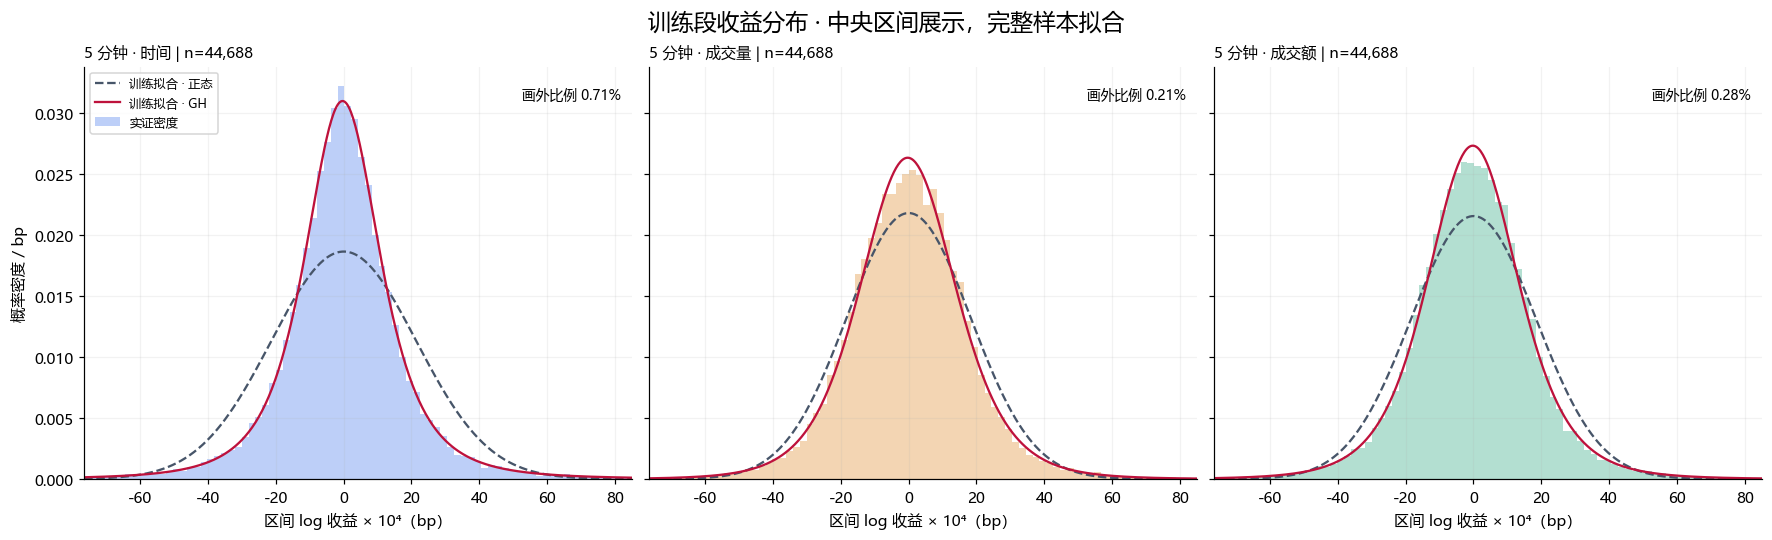

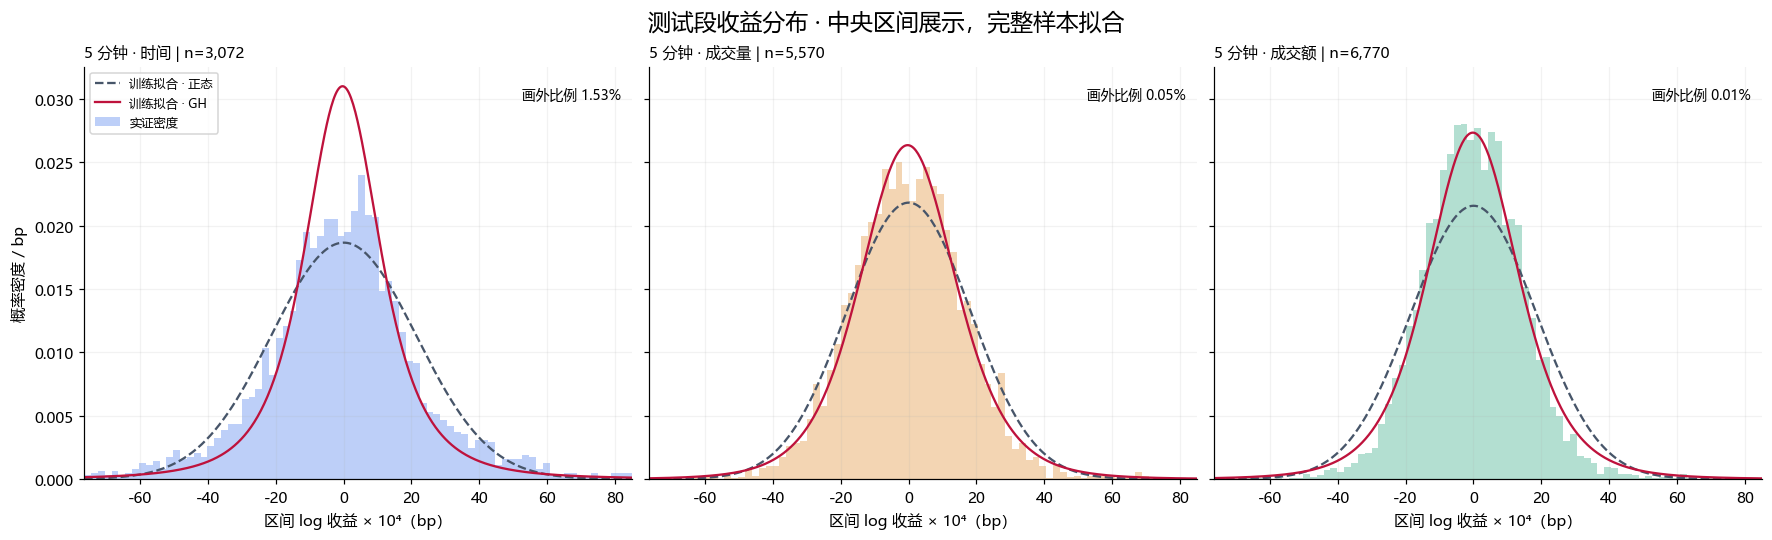

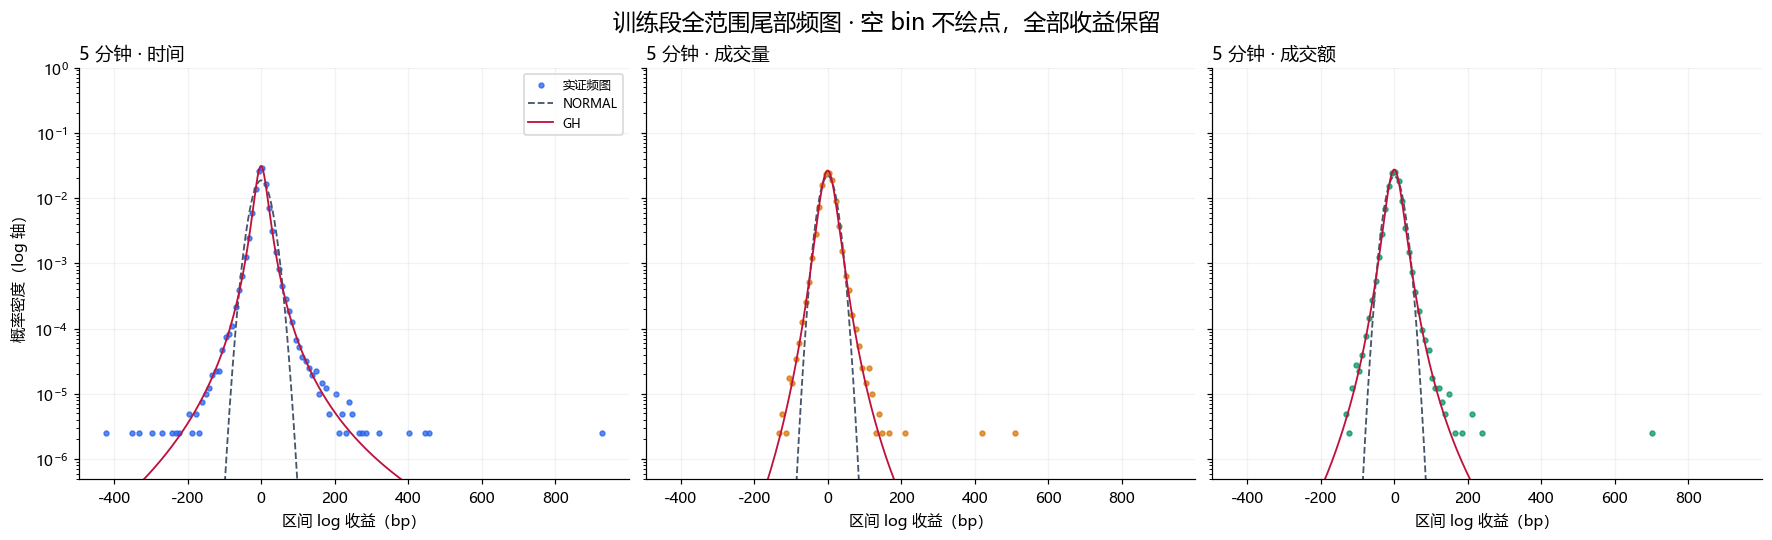

In [5]:
# 同粒度的三个时钟使用同一组训练期横轴和 bin，测试图沿用，不用测试信息调范围。
histogram_edges_by_granularity = {}
for granularity in granularities:
    combined_training_returns = np.concatenate([
        interval_by_group[(granularity, clock, "train")]["return_bp"].to_numpy(dtype=float) for clock in clocks
    ])
    lower, upper = np.quantile(combined_training_returns, central_quantiles)
    histogram_edges_by_granularity[granularity] = np.linspace(lower, upper, histogram_bins + 1)

for split in splits:
    figure, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey="row", squeeze=False, layout="constrained")
    for row, granularity in enumerate(granularities):
        edges = histogram_edges_by_granularity[granularity]
        centers = (edges[:-1] + edges[1:]) / 2
        model_grid = np.linspace(edges[0], edges[-1], 500)
        for column, clock in enumerate(clocks):
            axis = axes[row, column]
            returns = interval_by_group[(granularity, clock, split)]["return_bp"].to_numpy(dtype=float)
            counts, _ = np.histogram(returns, bins=edges)
            density = counts / (len(returns) * np.diff(edges))
            axis.bar(centers, density, width=np.diff(edges), color=clock_colors[clock],
                     alpha=0.3, edgecolor="none", label="实证密度")
            models = fit_by_group[(granularity, clock)]
            axis.plot(model_grid, stats.norm.pdf(model_grid, *models["normal"]),
                      color="#475569", linestyle="--", linewidth=1.5, label="训练拟合 · 正态")
            axis.plot(model_grid, stats.genhyperbolic.pdf(model_grid, *models["gh"]),
                      color="#BE123C", linewidth=1.5, label="训练拟合 · GH")
            outside_fraction = 1 - counts.sum() / len(returns)
            axis.set_title(f"{granularity} 分钟 · {clock_labels[clock]} | n={len(returns):,}", loc="left", fontsize=10)
            axis.text(0.98, 0.95, f"画外比例 {outside_fraction:.2%}", ha="right", va="top", transform=axis.transAxes, fontsize=9)
            axis.set_xlim(edges[0], edges[-1])
            if column == 0: axis.set_ylabel("概率密度 / bp")
            if row == 0: axis.set_xlabel("区间 log 收益 × 10⁴（bp）")
            if row == 0 and column == 0: axis.legend(fontsize=8, loc="upper left")
    figure.suptitle(f"{'训练段' if split == 'train' else '测试段'}收益分布 · 中央区间展示，完整样本拟合", fontsize=15)
    plt.show()
    plt.close(figure)

# 全部训练范围的 log-density 频图：保留极端收益，对照两个模型的尾部形状。
figure, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey="row", squeeze=False, layout="constrained")
for row, granularity in enumerate(granularities):
    pooled_returns = np.concatenate([
        interval_by_group[(granularity, clock, "train")]["return_bp"].to_numpy(dtype=float) for clock in clocks
    ])
    edges = np.linspace(pooled_returns.min(), pooled_returns.max(), 151)
    model_grid = np.linspace(edges[0], edges[-1], 900)
    for column, clock in enumerate(clocks):
        axis = axes[row, column]
        returns = interval_by_group[(granularity, clock, "train")]["return_bp"].to_numpy(dtype=float)
        counts, _ = np.histogram(returns, bins=edges)
        density = counts / (len(returns) * np.diff(edges))
        visible = counts > 0
        axis.scatter(((edges[:-1] + edges[1:]) / 2)[visible], density[visible],
                     color=clock_colors[clock], s=10, alpha=0.75, label="实证频图")
        models = fit_by_group[(granularity, clock)]
        for model, distribution, color, linestyle in [
            ("normal", stats.norm, "#475569", "--"), ("gh", stats.genhyperbolic, "#BE123C", "-")
        ]:
            model_density = distribution.pdf(model_grid, *models[model])
            axis.plot(model_grid, np.where(model_density > 0, model_density, np.nan),
                      color=color, linestyle=linestyle, linewidth=1.2, label=model.upper())
        axis.set_yscale("log")
        axis.set_ylim(max(1e-8, 0.2 / (len(returns) * np.diff(edges)[0])), max(1.0, density.max() * 3))
        axis.set_title(f"{granularity} 分钟 · {clock_labels[clock]}", loc="left")
        if column == 0: axis.set_ylabel("概率密度（log 轴）")
        if row == 0: axis.set_xlabel("区间 log 收益（bp）")
        if row == 0 and column == 0: axis.legend(fontsize=8)
figure.suptitle("训练段全范围尾部频图 · 空 bin 不绘点，全部收益保留", fontsize=15)
plt.show()
plt.close(figure)


## 6. 简单的检验性时序描述

描述统计以采样区间为单位，不把不同实际时长的收益擅自年化。收益与平方收益 ACF 展示前 40 个事件 lag；同分钟拆分率和跨休市比例帮助区分插值、休市与市场波动的影响。

| 检验 | 原假设与解读 |
|---|---|
| Jarque–Bera | 偏度、峰度符合正态；拒绝提示形状不符，不能单凭不拒绝证明正态 |
| Ljung–Box（收益／平方收益） | 前 10 个 lag 联合不相关 |
| ARCH-LM（10 lag） | 不存在所检验阶数的 ARCH 效应 |
| ADF（log 价格／收益） | 存在单位根；常数项，最多 10 lag，BIC 选阶 |

每个检验族在所选粒度的 6 个子序列之间给出 BH-FDR 校正 q 值。时序依赖、插值和厚尾会影响名义检验条件，因此这些结果只作为探索性诊断，不计算带有“已知参数”假设的普通 KS 拟合 p 值。

方法说明：[Ljung–Box](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html)、[ARCH-LM](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.het_arch.html)、[ADF](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html)。

sample_count  mean_bp   std_bp  skewness  excess_kurtosis    min_bp   q01_bp   q05_bp  median_bp   q95_bp   q99_bp    max_bp  zero_return_fraction  same_source_minute_fraction  mean_calendar_duration_minutes  mean_trading_duration_minutes  \
equivalent_minutes clock  split                                                                                                                                                                                                                                                   
5                  money  test           6770  -0.1178  14.7725    0.1162           1.1767  -80.0301 -35.3322 -23.3318    -0.2508  23.2160  36.5704   73.5431                   0.0                       0.0425                         18.7664                         2.2686   
                          train         44688   0.0395  18.4944    1.5072          51.9147 -131.7896 -46.9380 -27.7553    -0.0621  27.7716  49.5556  703.6760                   0.0                       0.0224                         45.2491                         5.0000   
                   time   test           3072  -0.2589  27.6232    1.0293          20.7973 -201.0794 -72.0378 -39.5055    -0.3194  40.5074  74.3226  397.4528                   0.0                       0.0000                         41.3574                         5.0000   
                          train         44688   0.0395  21.3795    2.5943         113.9770 -427.1895 -54.6710 -28.1491    -0.0795  28.6058  57.8635  931.8262                   0.0                       0.0000                         45.2491                         5.0000   
                   volume test           5570  -0.1434  16.6218    0.1370           1.0069  -81.6838 -38.3576 -26.6246    -0.3082  26.6931  40.0276   91.8332                   0.0                       0.0280                         22.8093                         2.7572   
                          train         44688   0.0395  18.2852    0.9289          22.8902 -130.9049 -45.8438 -27.6670    -0.0026  27.9167  47.7525  508.7435                   0.0                       0.0187                         45.2491                         5.0000   

                                 median_trading_duration_minutes  p95_trading_duration_minutes  recess_spanning_fraction  return_acf_lag1  squared_return_acf_lag1  
equivalent_minutes clock  split                                                                                                                                     
5                  money  test                            2.1194                        4.3674                    0.0188           0.1948                   0.3193  
                          train                           3.4365                       15.3591                    0.0416           0.1415                   0.1427  
                   time   test                            5.0000                        5.0000                    0.0413          -0.0026                   0.0578  
                          train                           5.0000                        5.0000                    0.0416           0.0018                   0.0567  
                   volume test                            2.5632                        5.3328                    0.0228           0.1818                   0.2324  
                          train                           3.5284                       15.0612                    0.0416           0.1536                   0.4393

jb_statistic          jb_p  lb_return_statistic    lb_return_p  lb_squared_statistic   lb_squared_p  arch_lm_statistic         arch_p  adf_return_statistic  adf_return_p  adf_return_used_lags  adf_log_price_statistic  adf_log_price_p  adf_log_price_used_lags  \
equivalent_minutes clock  split                                                                                                                                                                                                                                                                       
5                  money  test   4.046604e+02  1.346198e-88           291.275967   1.084237e-56           3398.738438   0.000000e+00        1217.541458  2.369702e-255            -67.528812           0.0                     0                -1.201308         0.673033                        1   
                          train  5.034120e+06  0.000000e+00           978.271500  8.955875e-204           1207.642682  3.236145e-253        1047.102590  1.328959e-218           -136.168918           0.0                     1                -0.854679         0.802531                        2   
                   time   test   5.571491e+04  0.000000e+00            23.256713   9.837657e-03             89.954351   5.468726e-15          61.733417   1.700456e-09            -55.544591           0.0                     0                -1.243616         0.654558                        0   
                          train  2.423344e+07  0.000000e+00            41.175808   1.050345e-05            655.899107  1.826622e-134         534.746019  1.644969e-108           -211.028835           0.0                     0                -0.830644         0.809954                        0   
                   volume test   2.517719e+02  2.130283e-55           205.088937   1.399735e-38           1248.264625  5.577813e-262         590.007653  2.434860e-120            -62.084501           0.0                     0                -1.239890         0.656205                        1   
                          train  9.818092e+05  0.000000e+00          1134.720738  1.725101e-237           9399.014992   0.000000e+00       10614.038580   0.000000e+00           -181.094418           0.0                     0                -0.768252         0.828270                        1   

                                         jb_q    lb_return_q   lb_squared_q         arch_q  adf_return_q  adf_log_price_q  
equivalent_minutes clock  split                                                                                            
5                  money  test   1.615438e-88   2.168474e-56   0.000000e+00  7.109107e-255           0.0          0.82827  
                          train  0.000000e+00  2.686762e-203  4.854218e-253  2.657919e-218           0.0          0.82827  
                   time   test   0.000000e+00   9.837657e-03   5.468726e-15   1.700456e-09           0.0          0.82827  
                          train  0.000000e+00   1.260414e-05  2.191947e-134  1.973963e-108           0.0          0.82827  
                   volume test   2.130283e-55   2.099602e-38  1.115563e-261  3.652289e-120           0.0          0.82827  
                          train  0.000000e+00  1.035060e-236   0.000000e+00   0.000000e+00           0.0          0.82827

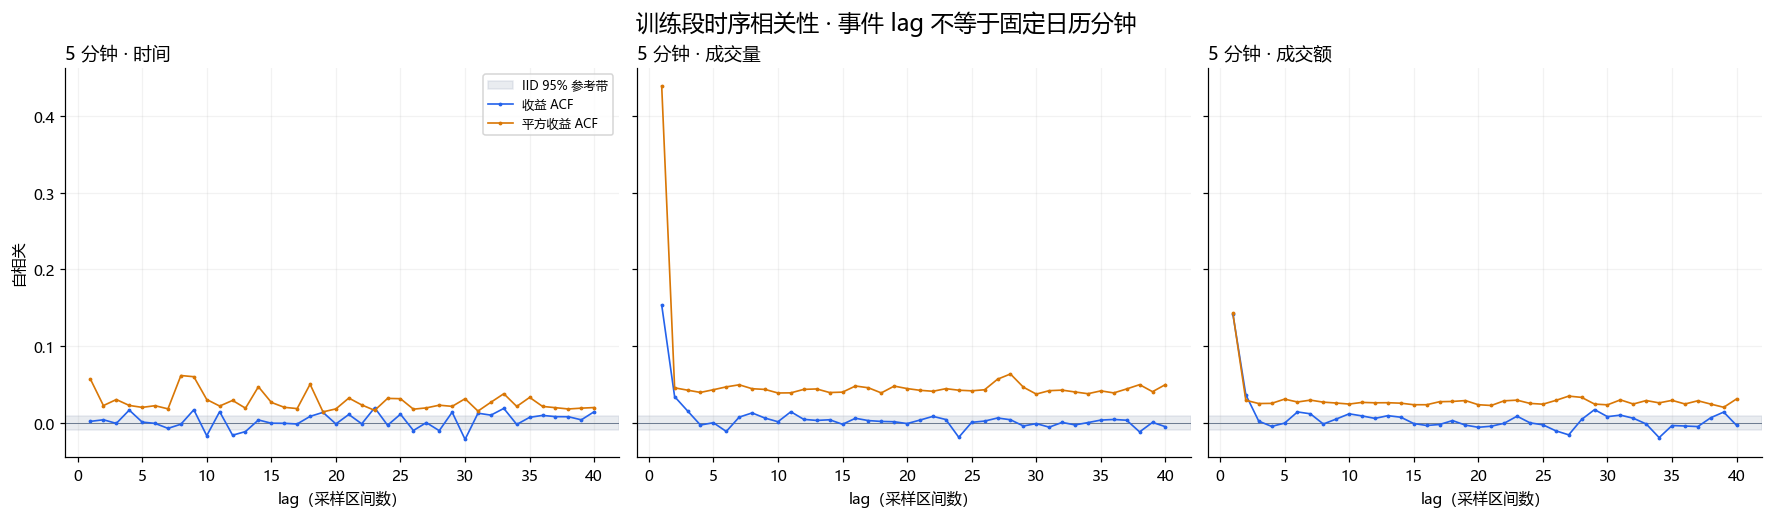

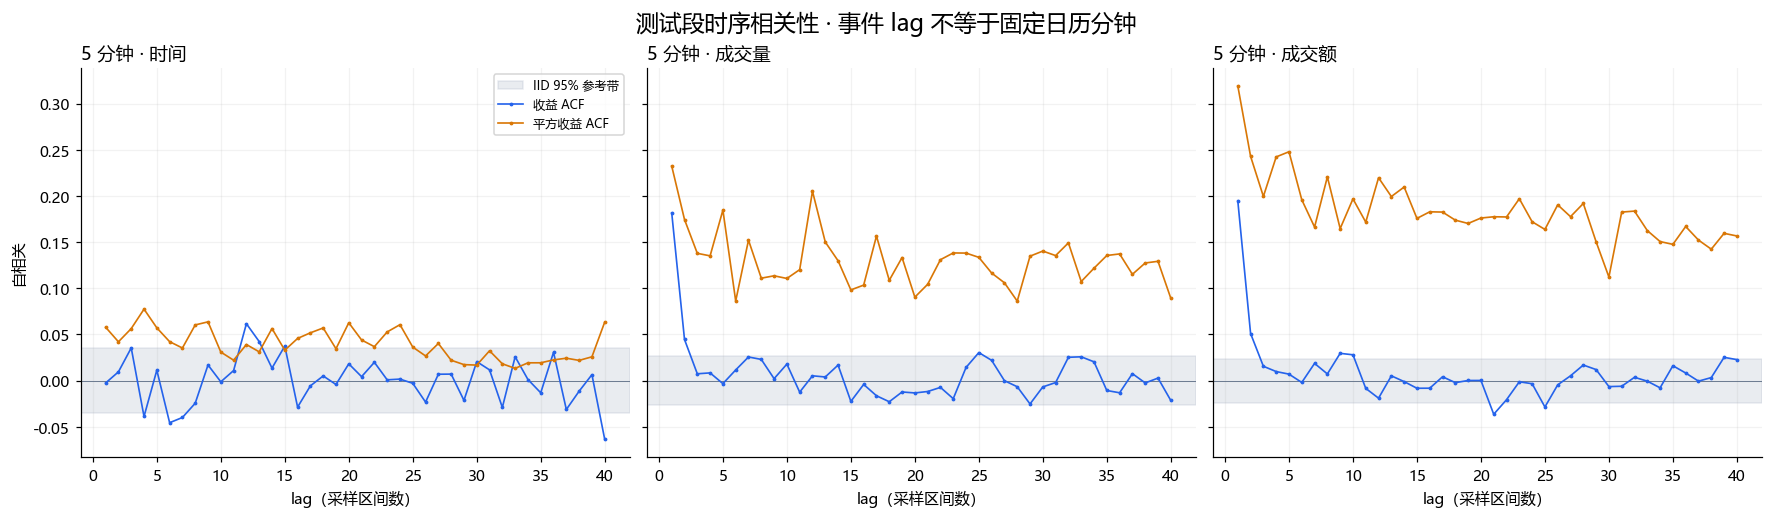

In [6]:
description_rows = []
test_rows = []
acf_by_group = {}
for (granularity, clock, split), series_df in interval_by_group.items():
    returns = series_df["return_bp"].to_numpy(dtype=float)
    log_prices = price_by_group[(granularity, clock, split)]["log_price"].to_numpy(dtype=float)
    quantiles = np.quantile(returns, [0.01, 0.05, 0.5, 0.95, 0.99])
    # FFT 的 ACF 同时返回 Ljung–Box Q 与 p 值，避免长序列的直接相关 O(n²) 计算。
    return_acf, return_q, return_q_p = acf(returns, nlags=acf_lags, fft=True, qstat=True)
    squared_acf, squared_q, squared_q_p = acf(returns ** 2, nlags=acf_lags, fft=True, qstat=True)
    acf_by_group[(granularity, clock, split)] = (return_acf, squared_acf)
    jarque_bera = stats.jarque_bera(returns)
    arch_lm, arch_p, _, _ = het_arch(returns - returns.mean(), nlags=diagnostic_lag, ddof=1)
    adf_returns = adfuller(returns, maxlag=diagnostic_lag, regression="c", autolag="BIC")
    adf_prices = adfuller(log_prices, maxlag=diagnostic_lag, regression="c", autolag="BIC")
    description_rows.append({
        "equivalent_minutes": granularity, "clock": clock, "split": split,
        "sample_count": len(returns),
        "mean_bp": float(returns.mean()), "std_bp": float(returns.std(ddof=1)),
        "skewness": float(stats.skew(returns, bias=False)),
        "excess_kurtosis": float(stats.kurtosis(returns, fisher=True, bias=False)),
        "min_bp": float(returns.min()), "q01_bp": quantiles[0], "q05_bp": quantiles[1],
        "median_bp": quantiles[2], "q95_bp": quantiles[3], "q99_bp": quantiles[4], "max_bp": float(returns.max()),
        "zero_return_fraction": float(np.mean(returns == 0)),
        "same_source_minute_fraction": float(series_df["same_source_minute"].mean()),
        "mean_calendar_duration_minutes": float(series_df["duration_seconds"].mean() / 60),
        "mean_trading_duration_minutes": float(series_df["trading_duration_minutes"].mean()),
        "median_trading_duration_minutes": float(series_df["trading_duration_minutes"].median()),
        "p95_trading_duration_minutes": float(series_df["trading_duration_minutes"].quantile(0.95)),
        "recess_spanning_fraction": float((series_df["nontrading_duration_seconds"] > 1e-4).mean()),
        "return_acf_lag1": float(return_acf[1]), "squared_return_acf_lag1": float(squared_acf[1]),
    })
    test_rows.append({
        "equivalent_minutes": granularity, "clock": clock, "split": split,
        "jb_statistic": float(jarque_bera.statistic), "jb_p": float(jarque_bera.pvalue),
        "lb_return_statistic": float(return_q[diagnostic_lag - 1]), "lb_return_p": float(return_q_p[diagnostic_lag - 1]),
        "lb_squared_statistic": float(squared_q[diagnostic_lag - 1]), "lb_squared_p": float(squared_q_p[diagnostic_lag - 1]),
        "arch_lm_statistic": float(arch_lm), "arch_p": float(arch_p),
        "adf_return_statistic": float(adf_returns[0]), "adf_return_p": float(adf_returns[1]),
        "adf_return_used_lags": int(adf_returns[2]),
        "adf_log_price_statistic": float(adf_prices[0]), "adf_log_price_p": float(adf_prices[1]),
        "adf_log_price_used_lags": int(adf_prices[2]),
    })

description_df = pd.DataFrame(description_rows).sort_values(["equivalent_minutes", "clock", "split"]).reset_index(drop=True)
test_df = pd.DataFrame(test_rows).sort_values(["equivalent_minutes", "clock", "split"]).reset_index(drop=True)
# 每一种检验在当前 6 个子序列间作 BH-FDR 校正；不把它当作依赖样本的严格保证。
p_columns = ["jb_p", "lb_return_p", "lb_squared_p", "arch_p", "adf_return_p", "adf_log_price_p"]
for p_column in p_columns:
    test_df[p_column.removesuffix("_p") + "_q"] = multipletests(test_df[p_column], method="fdr_bh")[1]
display(description_df.set_index(["equivalent_minutes", "clock", "split"]).round(4))
display(test_df.set_index(["equivalent_minutes", "clock", "split"]))

for split in splits:
    figure, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, sharey=True, squeeze=False, layout="constrained")
    for row, granularity in enumerate(granularities):
        for column, clock in enumerate(clocks):
            axis = axes[row, column]
            group = (granularity, clock, split)
            return_acf, squared_acf = acf_by_group[group]
            lags = np.arange(1, acf_lags + 1)
            axis.axhline(0, color="#64748B", linewidth=0.6)
            reference_band = 1.96 / np.sqrt(len(interval_by_group[group]))
            axis.axhspan(-reference_band, reference_band, color="#94A3B8", alpha=0.2, label="IID 95% 参考带")
            axis.plot(lags, return_acf[1:], color="#2563EB", linewidth=1.1, marker=".", markersize=3, label="收益 ACF")
            axis.plot(lags, squared_acf[1:], color="#D97706", linewidth=1.1, marker=".", markersize=3, label="平方收益 ACF")
            axis.set_title(f"{granularity} 分钟 · {clock_labels[clock]}", loc="left")
            if column == 0: axis.set_ylabel("自相关")
            if row == 0: axis.set_xlabel("lag（采样区间数）")
            if row == 0 and column == 0: axis.legend(fontsize=8)
    figure.suptitle(f"{'训练段' if split == 'train' else '测试段'}时序相关性 · 事件 lag 不等于固定日历分钟", fontsize=15)
    plt.show()
    plt.close(figure)


## 7. 简要结论

以下结论根据实际拟合、统计量和检验结果生成；结果属于当前上游价格快照的描述。

In [7]:
# 由实际结果生成简要描述，不预先断言哪种采样更好。
test_scores = fit_comparison_df.xs("test", level="split")
gh_test_wins = int((test_scores["gh_minus_normal"] > 0).sum())
rejection_counts = {
    name: int((test_df[column] < 0.05).sum())
    for name, column in [
        ("JB 正态性", "jb_q"), ("收益 Ljung–Box", "lb_return_q"),
        ("平方收益 Ljung–Box", "lb_squared_q"), ("ARCH-LM", "arch_q"),
        ("收益 ADF", "adf_return_q"), ("log 价格 ADF", "adf_log_price_q"),
    ]
}
summary_text = (
    f"共比较 {len(fit_df)} 组采样方案、{len(description_df)} 个训练／测试子序列。"
    f"GH 数值优化 {int(fit_df['success'].sum())}/{len(fit_df)} 组报告收敛，"
    f"{int(fit_df['boundary_hit'].sum())} 组触及搜索边界。\n\n"
    f"训练参数固定后，测试段 GH 的平均 log likelihood 在 {gh_test_wins}/{len(test_scores)} 组高于正态；"
    "这只是同一组收益内的密度描述比较，不能直接用不同组的似然总和给采样方式排名。\n\n"
    f"{len(description_df)} 个子序列的超额峰度范围为 {description_df['excess_kurtosis'].min():.2f} 至 "
    f"{description_df['excess_kurtosis'].max():.2f}。BH 校正后 q<0.05 的组数："
    + "；".join(f"{name} {count}/{len(test_df)}" for name, count in rejection_counts.items())
    + "。\n\n"
    "JB 拒绝表示偏度／峰度与正态不符；Ljung–Box 拒绝表示前 10 个 lag 联合相关；"
    "平方收益和 ARCH-LM 用于观察波动聚集。ADF 拒绝的是单位根原假设，不能据此证明独立同分布。"
    "大样本下同时看统计量、ACF 大小和图形；检验 p/q 值是探索性参考。"
)
display(Markdown(summary_text))

# 最小一致性检查：所选粒度的三种时钟仅使用训练收益拟合；六个子序列评估；正常参考点没有进入收益样本。
assert len(fit_df) == 3 and len(description_df) == 6 and len(evaluation_df) == 12
assert len(interval_df) == len(price_df) - len(expected_groups)
assert np.isfinite(fit_df[["gh_p", "gh_a", "gh_b", "gh_loc_bp", "gh_scale_bp"]].to_numpy()).all()
assert (fit_df["gh_a"] > np.abs(fit_df["gh_b"])).all() and (fit_df["gh_scale_bp"] > 0).all()
for fit_row in fit_df.itertuples(index=False):
    assert fit_row.train_count == len(interval_by_group[(fit_row.equivalent_minutes, fit_row.clock, "train")])
    training_returns = interval_by_group[(fit_row.equivalent_minutes, fit_row.clock, "train")]["return_bp"].to_numpy(dtype=float)
    np.testing.assert_allclose(fit_row.normal_mean_bp, training_returns.mean(), rtol=1e-12)
    np.testing.assert_allclose(fit_row.normal_std_bp, training_returns.std(ddof=0), rtol=1e-12)


共比较 3 组采样方案、6 个训练／测试子序列。GH 数值优化 3/3 组报告收敛，0 组触及搜索边界。

训练参数固定后，测试段 GH 的平均 log likelihood 在 3/3 组高于正态；这只是同一组收益内的密度描述比较，不能直接用不同组的似然总和给采样方式排名。

6 个子序列的超额峰度范围为 1.01 至 113.98。BH 校正后 q<0.05 的组数：JB 正态性 6/6；收益 Ljung–Box 6/6；平方收益 Ljung–Box 6/6；ARCH-LM 6/6；收益 ADF 6/6；log 价格 ADF 0/6。

JB 拒绝表示偏度／峰度与正态不符；Ljung–Box 拒绝表示前 10 个 lag 联合相关；平方收益和 ARCH-LM 用于观察波动聚集。ADF 拒绝的是单位根原假设，不能据此证明独立同分布。大样本下同时看统计量、ACF 大小和图形；检验 p/q 值是探索性参考。